In [ ]:
import pandas as pd
import os, re
import numpy as np
from pathlib import Path
from collections import Counter
from sklearn.metrics import cohen_kappa_score, confusion_matrix

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import rc
matplotlib.rcParams['figure.dpi'] = 360
matplotlib.rcParams['text.usetex'] = True

In [2]:
tiles = [
    # tile 1008
    dict(
        good_v=[1946, 4423],
        out_v=[186,201,222,486,986,2111,2116,2315,2485,3234,3477,3660,
               3780,3797,3919,4177,4213,4214,4544,4559,4677,4722,4918,
               4986,4988],
        good_j=[1946, 4423],
        out_j=[186,201,222,486,986,2111,2116,2315,2485,3234,3477,3660,
               3780,3797,3919,4177,4213,4214,4544,4559,4677,4722,4918,
               4986,4988]
    ),

    # tile 7441
    dict(
        good_v=[],
        out_v=[483,1102,1143,1504,1533,1581,1657,1684,1922,2027,2039,
               2098,2444,2453,2551,2573,2595,3000,3087,3195,3243,
               4175,4358,4570,4707,4767],
        good_j=[],
        out_j=[483,1102,1143,1504,1533,1581,1657,1684,1922,2027,2039,
               2098,2444,2453,2551,2573,2595,3000,3087,3195,3243,
               4175,4358,4570,4707,4767]
    ),

    # tile 83445
    dict(
        good_v=[2453,2471,2779,4566],
        out_v=[18,39,88,95,97,100,103,110,113,115,130,177,185,199,
               308,319,337,342,343,364,371,399,415,417,429,432,
               441,447,453,491,675,938,1136,1477,1481,1501,1515,
               1664,1673,1686,1699,1702,1713,1716,1726,1743,1752,
               1754,1757,1761,1803,1808,1834,1865,1918,2407,2618,
               2867,2875,2961,3017,3079,3169,3254,3391,3539,3794,
               3885,4384,4418,4440,4452,4483,4822,4824,4906],
        good_j=[2453,2471,2779,4384,4566],
        out_j=[18,39,88,95,97,100,103,110,113,115,130,177,185,199,
               308,319,337,342,343,364,371,399,415,417,429,432,
               441,447,453,491,675,938,1136,1477,1481,1501,1515,
               1664,1673,1686,1699,1702,1713,1716,1726,1743,1752,
               1754,1757,1761,1803,1808,1834,1865,1918,2407,2618,
               2867,2875,2961,3017,3079,3169,3254,3391,3539,3794,
               3885,4418,4440,4452,4483,4822,4824,4906]
    ),

    # tile 52
    dict(
        good_v=[3933,4909],
        out_v=[370,515,1020,1024,1082,1511,1512,1536,1562,1615,
               1694,1699,1725,1739,1796,1806,1857,1876,1884,
               1902,1907,1941,1953,1998,1999,2303,2563,3270,
               3362,3370,3467,3581,3811,3976,4568,4619,4738,
               4897,4899,4999],
        good_j=[1796,3270,3933,4909],
        out_j=[370,515,1020,1024,1082,1511,1512,1536,1562,1615,
               1694,1699,1725,1739,1806,1857,1876,1884,1902,
               1907,1941,1953,1998,1999,2303,2563,3270,3362,
               3467,3581,3811,3976,4568,4619,4738,4897,4899,4999]
    )
]

In [3]:
def confusion_from_lists(good_v, out_v, good_j, out_j):
    good_v = set(good_v)
    out_v  = set(out_v)
    good_j = set(good_j)
    out_j  = set(out_j)

    TP = len(good_v & good_j)
    FP = len(good_v & out_j)
    FN = len(out_v  & good_j)
    TN = len(out_v  & out_j)

    return np.array([[TP, FP],
                     [FN, TN]])

In [4]:
cm_global = np.zeros((2,2), dtype=int)

for tile in tiles:
    cm_global += confusion_from_lists(**tile)

In [5]:
cm_global

array([[  8,   0],
       [  3, 164]])

In [6]:
cm_norm = cm_global / cm_global.sum(axis=1, keepdims=True)

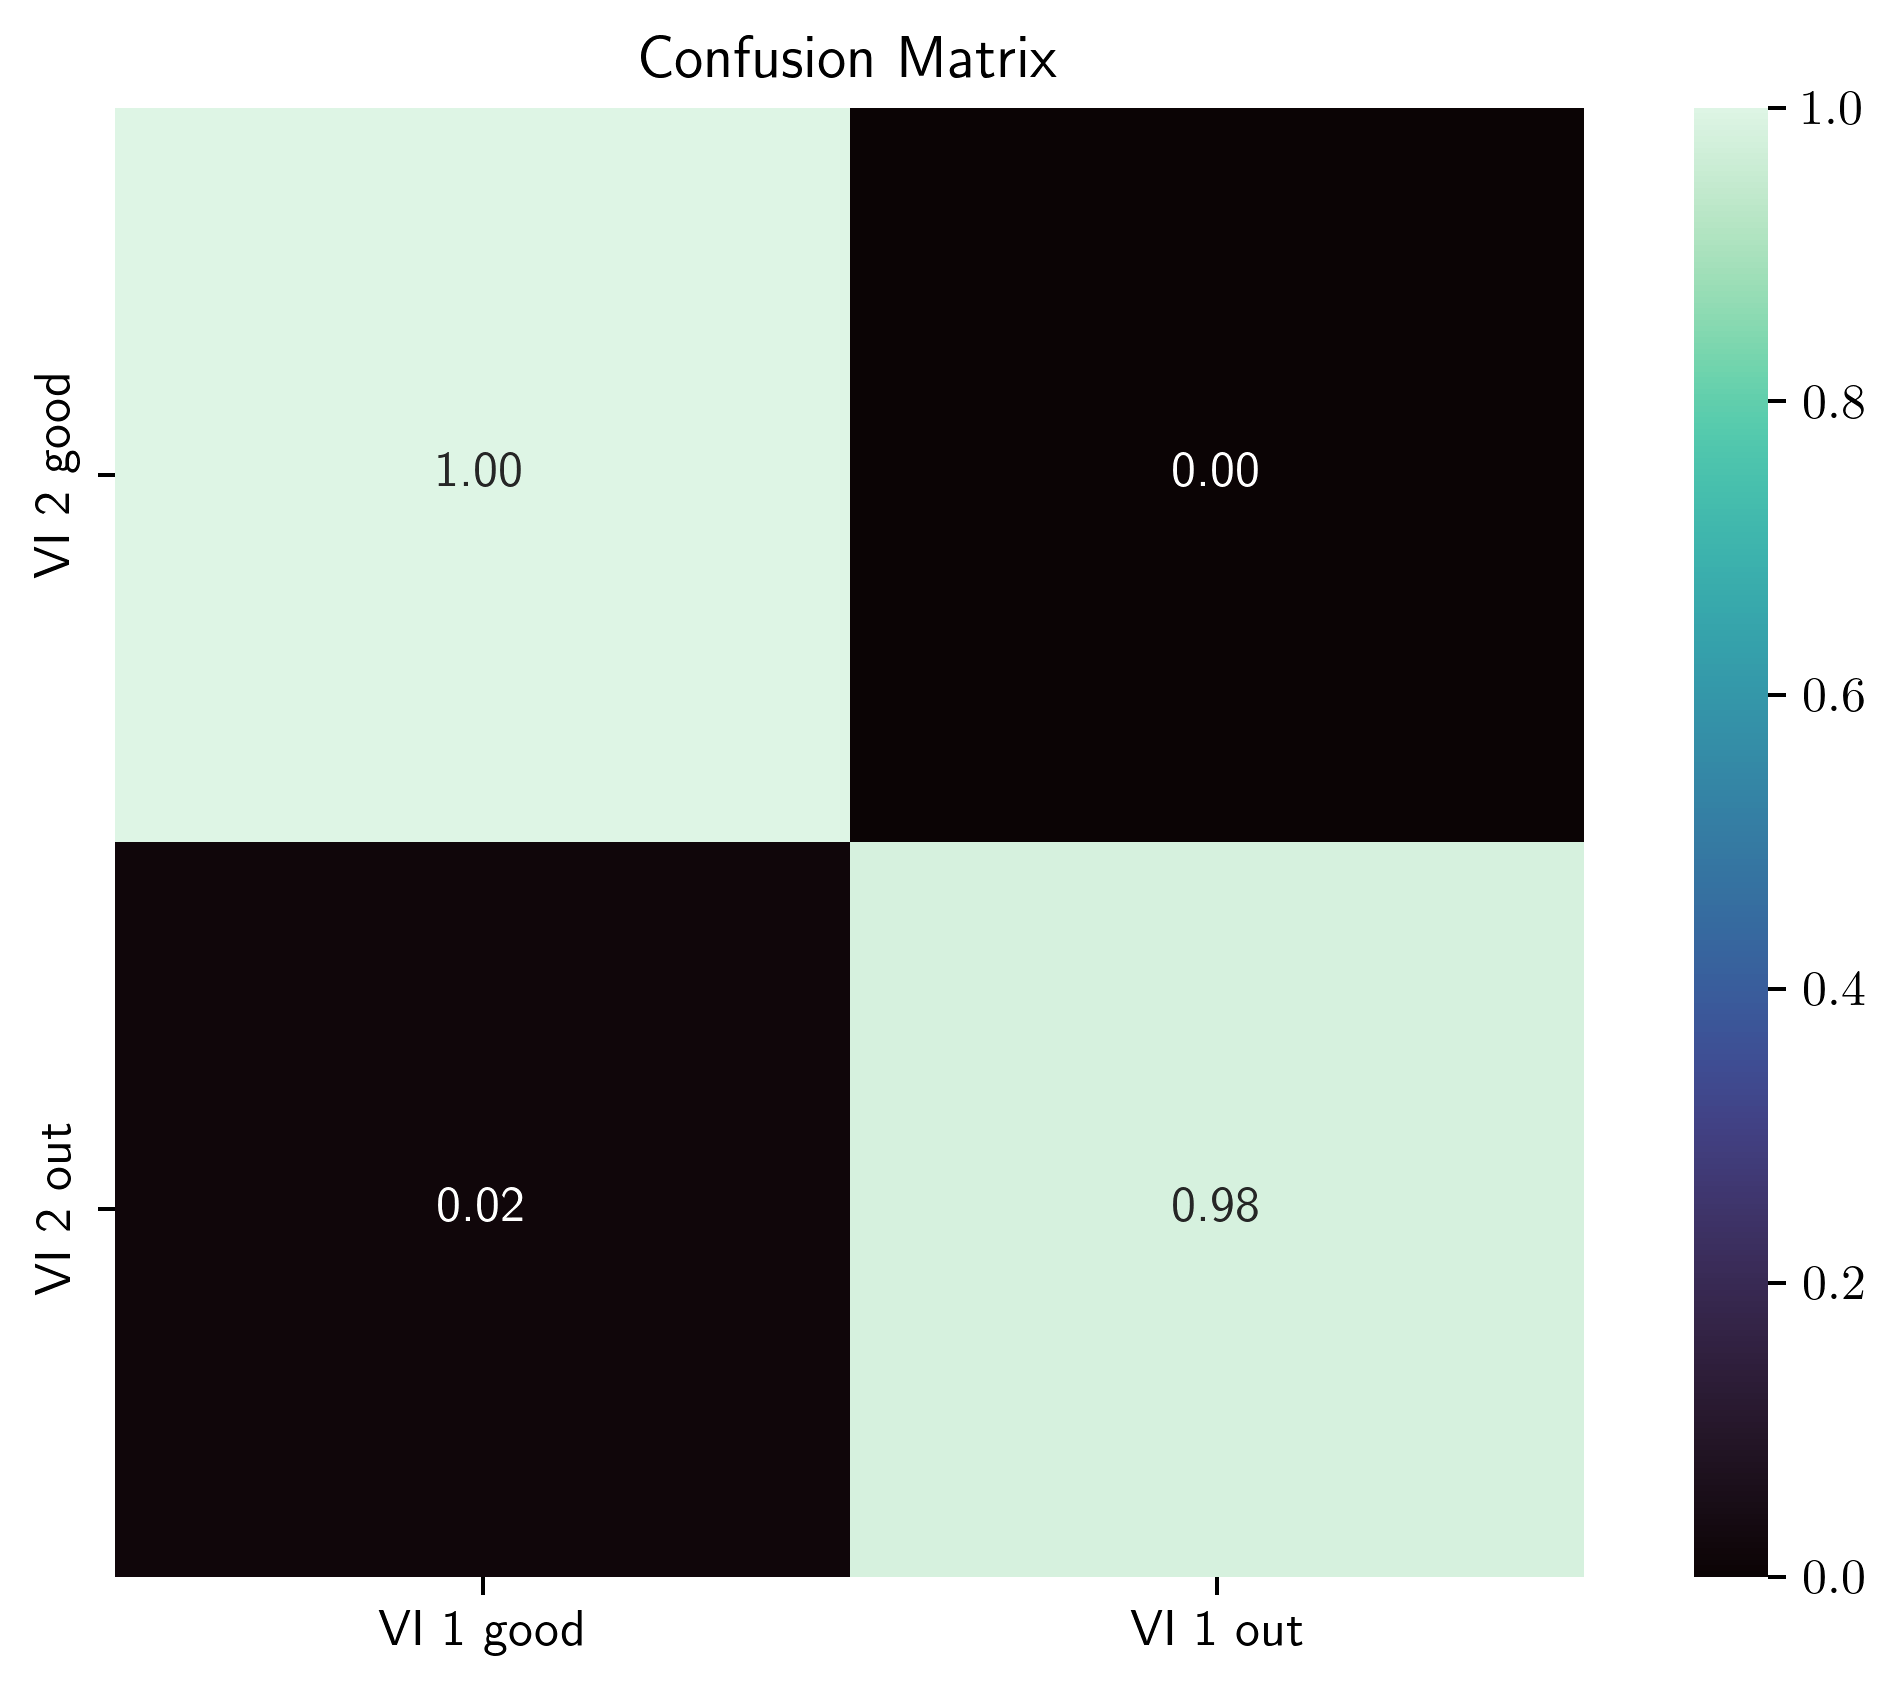

In [7]:
plt.figure()
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="mako",
    square=True,
    # cbar_kws={"label": r"\%"},
    xticklabels=["VI 1 good", "VI 1 out"],
    yticklabels=["VI 2 good", "VI 2 out"]
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig('matrix.png', dpi=360)
plt.show()

In [8]:
# -1 = good
# 1 = gap between cameras
# 2 = big fluctuations
# 3 = med/small fluctuations
# 4 = neg flux
# 5 = possible false OII
# 6 = spikes/drops in Z
# 7 = sky subtraction issue
# 8 = missing camera
# 9 = spikes/drops in R
# 10 = no data

In [9]:
causes_1008 = {
    186:  [1, 3],
    201:  [1, 3],
    222:  [2, 5],
    486:  [1, 3, 4],
    986:  [1, 2, 5],
    1946: [-1],
    2111: [1, 3, 5],
    2116: [2, 5],
    2315: [1, 2, 5],
    2485: [1, 3],
    3234: [1, 3, 5],
    3477: [1, 3],
    3660: [6],
    3780: [1, 3, 4],
    3797: [1, 3, 4, 5],
    3919: [1, 3, 5],
    4177: [1, 3, 5],
    4213: [2, 5],
    4214: [2, 5],
    4423: [-1],
    4544: [1, 3, 5],
    4559: [1, 2, 5],
    4667: [2, 5],
    4722: [1, 2, 5],
    4896: [2, 5],
    4918: [3, 5],
    4988: [1, 3, 5],
}


In [10]:
causes_7441 = {

    483:  [2, 5],                 # Large Z fluctuation ~9400 + OII confusion
    1102: [1, 2, 7],              # Gap RZ + large wiggles + sky subtraction
    1143: [1, 2, 5],              # Gaps + large Z wiggles + OII confusion
    1504: [1, 2, 7],
    1533: [2],                    # Large wiggles Z
    1581: [1, 3],
    1657: [1, 2, 7],
    1684: [1, 3, 7],
    1922: [1, 3, 5],
    2027: [1, 2, 8],              # Gaps + wiggles + Z missing
    2039: [1, 3, 7],
    2098: [3],
    2444: [2, 7],
    2453: [1, 3, 5, 7],
    2551: [1, 3, 7],
    2573: [1, 3],
    2595: [1, 3],
    3000: [1, 3],
    3087: [1, 3],
    3195: [1, 2, 5],
    3243: [1, 2, 5],
    4175: [2, 5],
    4358: [2],
    4570: [2, 7],
    4707: [2],
    4767: [3]
}


In [11]:
causes_83445 = {

    18:   [2, 6, 9],
    39:   [1, 9],
    88:   [2, 4],
    95:   [2, 9],
    97:   [4, 6, 9],
    100:  [4, 6],
    103:  [2, 5],
    110:  [4, 6],
    113:  [4, 6],
    115:  [4, 6],
    130:  [1, 4, 6],
    177:  [2],
    185:  [1, 2],
    199:  [1, 2],
    308:  [6, 9],
    319:  [6, 9],
    337:  [6, 9],
    342:  [1, 6],
    343:  [3, 4],
    364:  [1, 4, 6],
    371:  [3],
    399:  [4, 6],
    415:  [2, 6],
    417:  [2, 6],
    429:  [1, 2, 6],
    432:  [2, 6],
    441:  [2, 6],
    447:  [4, 6],
    453:  [1, 2, 6],
    491:  [6, 9],
    675:  [1],
    938:  [1, 4, 6],
    1136: [1, 4, 6],
    1477: [1, 4, 6],
    1481: [1, 4, 6],
    1501: [1],
    1515: [1],
    1664: [1, 4],
    1673: [1, 4],
    1686: [1, 2],
    1699: [4],
    1702: [1, 4],
    1713: [1, 2],
    1716: [4, 9],
    1726: [1],
    1743: [1],
    1752: [1],
    1754: [1],
    1757: [1],
    1761: [1],
    1803: [1, 4],
    1808: [1, 4],
    1834: [1, 9],
    1865: [1, 4],
    1918: [1],
    2407: [1, 2, 4, 6],
    2453: [-1],
    2471: [-1],
    2618: [2, 1],
    2779: [-1],
    2867: [1, 4, 9],
    2875: [1],
    2961: [4, 9],
    3071: [1],
    3079: [4, 9],
    3169: [1, 2],
    3254: [1],
    3391: [1],
    3539: [1],
    3794: [1, 3],
    3885: [1, 2],
    4384: [-1],
    4418: [1],
    4440: [1, 4, 9],
    4452: [1, 4, 9],
    4483: [1],
    4566: [-1],
    4822: [1, 4, 6],
    4824: [1],
    4906: [1, 4, 6]
}


In [12]:
causes_52 = {

    370:  [1, 2, 3, 4, 5],   # gaps + big B fluctuations + smaller R/Z + goes negative + OII confusion
    515:  [1],               # looks good but small RZ gap
    1020: [1],
    1024: [1],
    1082: [1],
    1511: [1],
    1512: [1],
    1536: [1],
    1562: [1],
    1615: [1],
    1694: [1],
    1699: [1],
    1725: [1],
    1739: [1],
    1796: [-1],
    1806: [1],
    1857: [1],
    1876: [1],
    1884: [1],
    1902: [1],
    1907: [1],
    1941: [1],
    1953: [1],
    1998: [1],
    1999: [1],

    2303: [1, 2, 5],         # medium gaps + large B fluctuations + OII confusion (Z)
    2563: [1],

    3270: [-1],
    3362: [1, 2],            # medium BR gap + large B fluctuations
    3370: [1],
    3467: [1],

    3581: [1, 2, 3, 5],      # large gaps + large B fluctuations + small R/Z + OII confusion (Z)
    3811: [1, 2, 3, 5],      # large BR gap + large B fluctuations + small R/Z + OII confusion (R)

    3933: [-1],
    3976: [1],
    4568: [1, 2, 5],         # large gaps + large B fluctuations + OII confusion (R)
    4619: [1],
    4738: [1, 2],            # large RZ gap + large B fluctuations

    4897: [10],
    4899: [10],

    4909: [-1],
    4999: [1, 2, 5],         # small gaps + large B fluctuations + OII confusion (B)
}

In [18]:
causes_global = {}

for d in [causes_1008, causes_7441, causes_83445, causes_52]:
    causes_global.update(d)


In [19]:
all_causes = []

for listx in causes_global.values():
    all_causes.extend(listx)

count_ = Counter(all_causes)
count_

Counter({1: 118,
         2: 51,
         4: 34,
         3: 31,
         5: 31,
         6: 29,
         9: 15,
         -1: 11,
         7: 8,
         10: 2,
         8: 1})

In [21]:
df = pd.DataFrame({
    "cause": list(count_.keys()),
    "freq": list(count_.values())
})

df = df.sort_values("cause")

In [22]:
df["percent"] = 100 * df["freq"] / df["freq"].sum()

In [17]:
labels_causes = {
    -1: "Good",
    1: "Cam gap",
    2: "Large Fluct",
    3: "Small Fluct",
    4: "Neg Flux",
    5: "False OII",
    6: "Z Artifact",
    7: "Sky Sub",
    8: "Missing Cam",
    9: "R Artifact",
    10: "No Data"
}

In [23]:
all_causes = []

for listx in causes_global.values():
    all_causes.extend(listx)

count_ = Counter(all_causes)

In [24]:
df = pd.DataFrame({
    "cause": [labels_causes[k] for k in count_.keys()],
    "freq": list(count_.values())
})

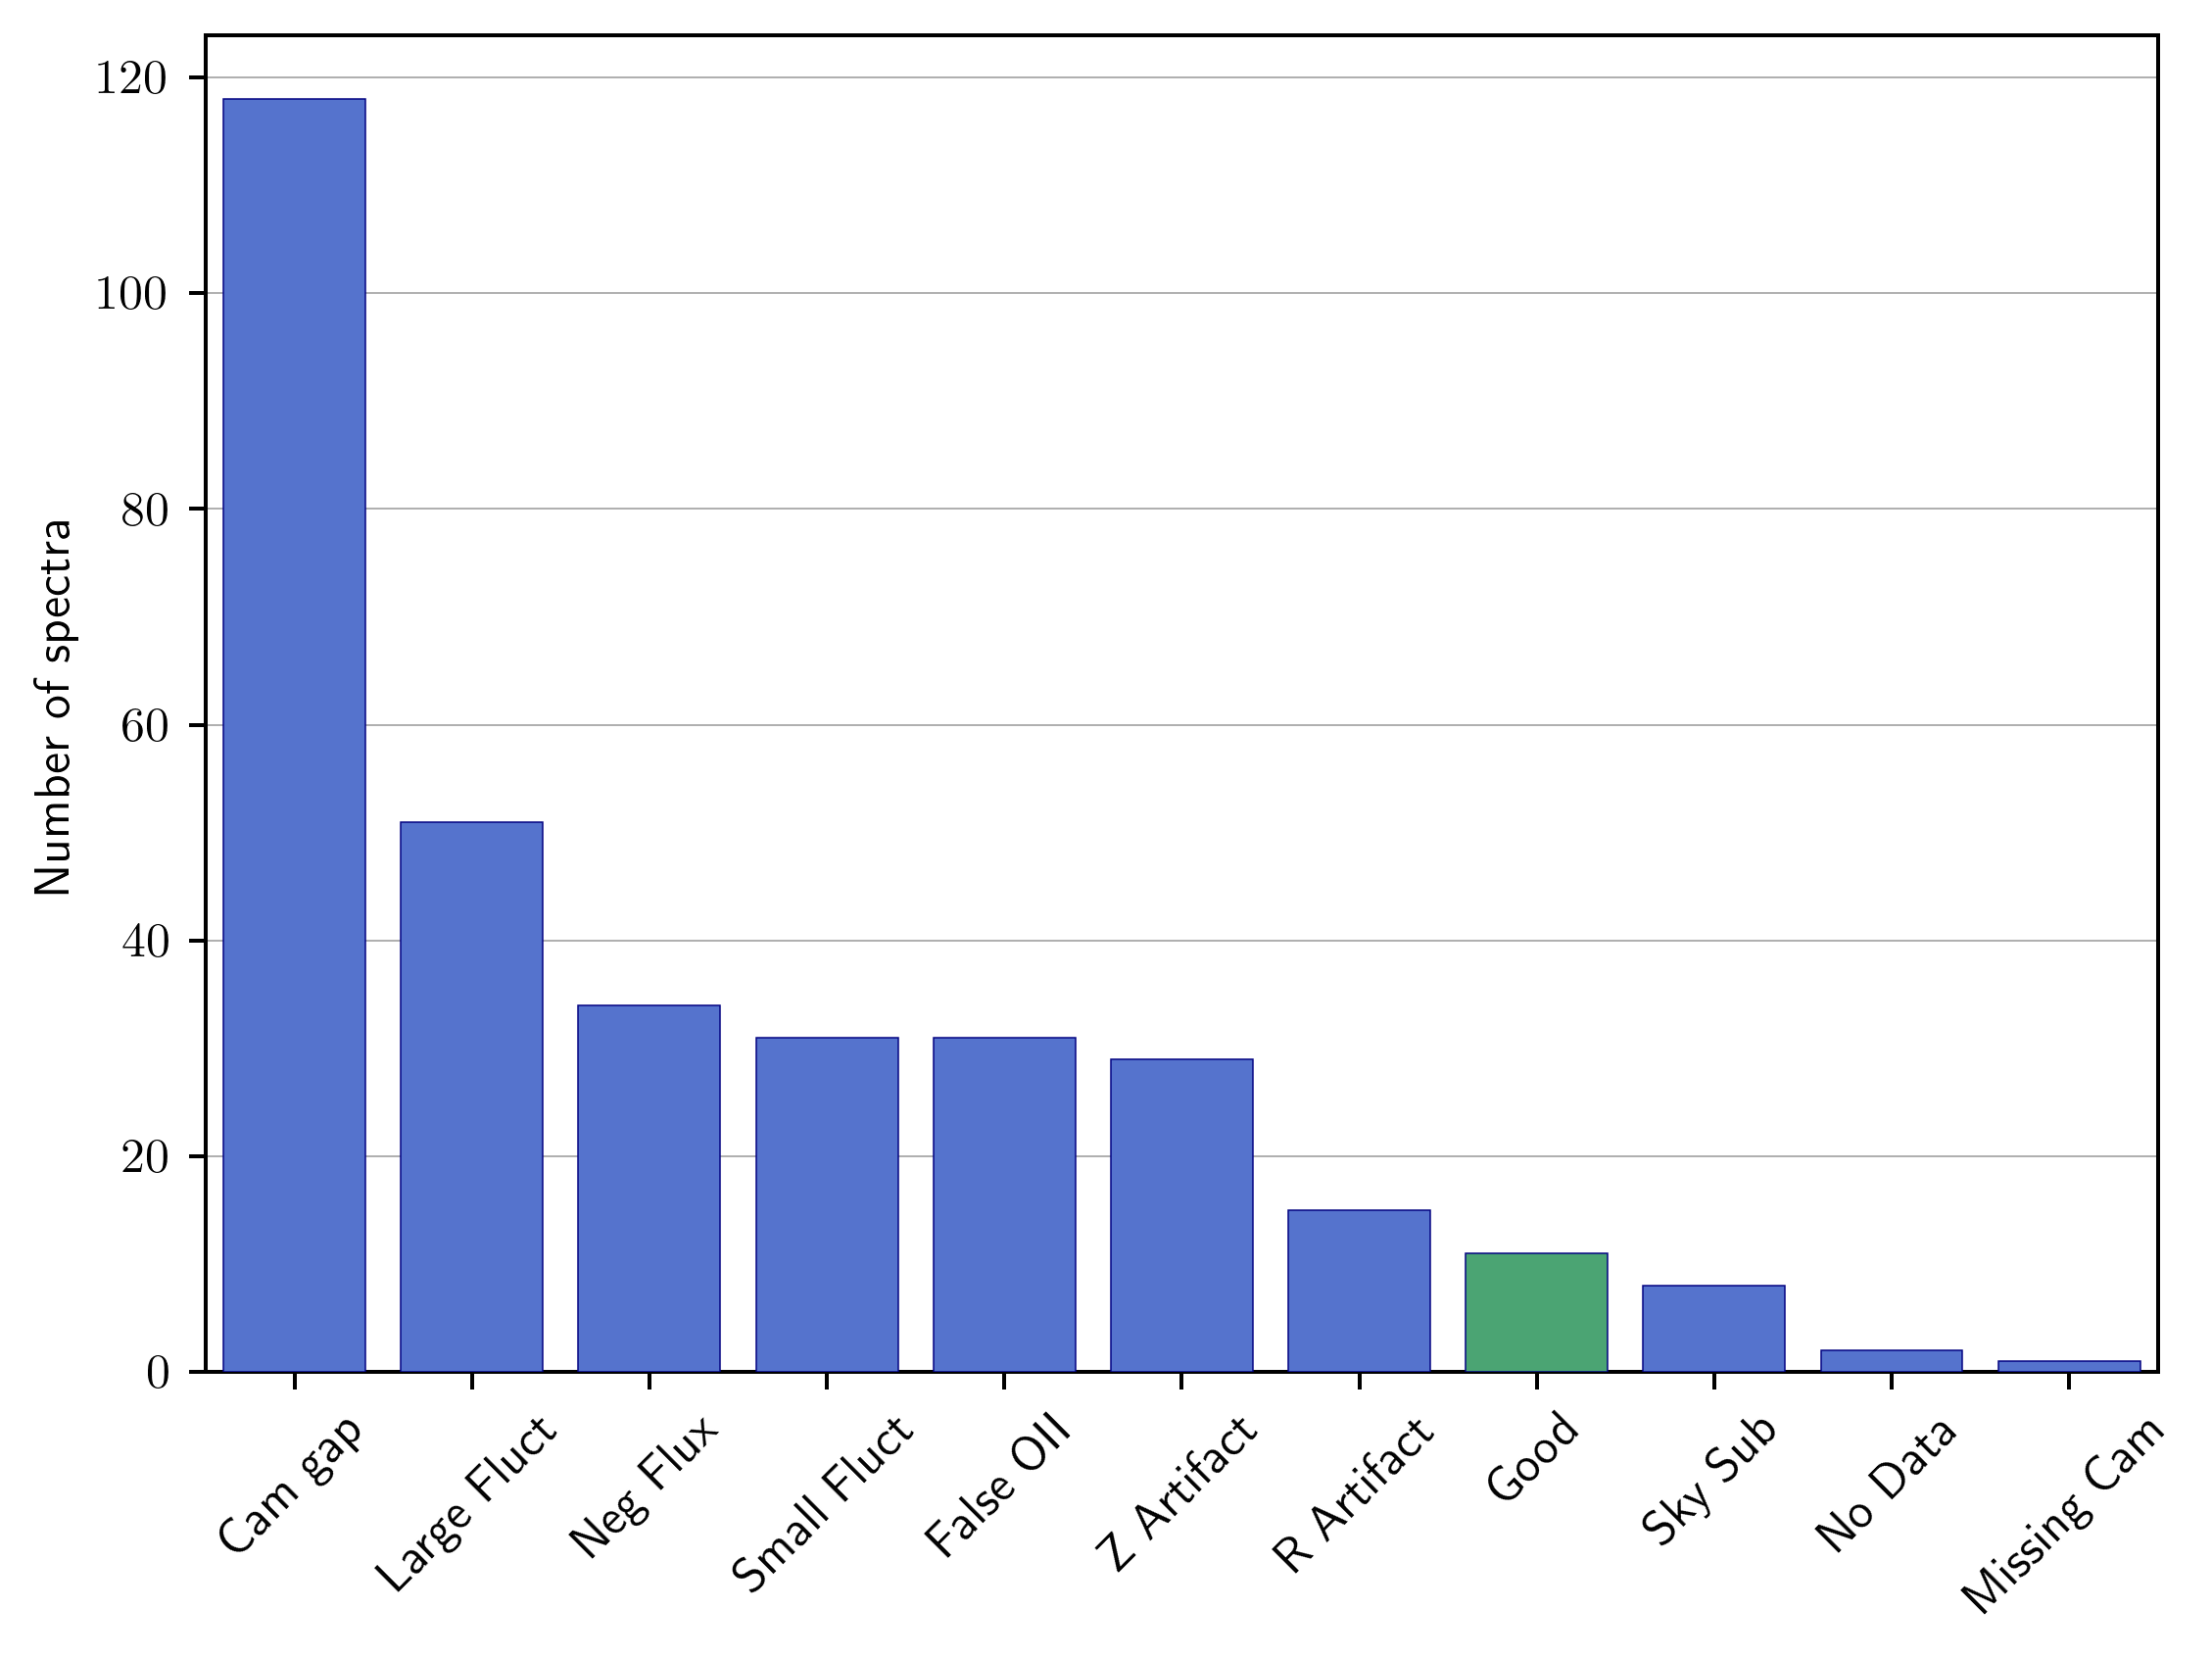

In [25]:
df_sorted = df.sort_values("freq", ascending=False)

colors = [
    "mediumseagreen" if cause == "Good" else "royalblue"
    for cause in df_sorted["cause"]
]

plt.figure()
plt.grid(axis='y', lw=0.4, zorder=-1)

sns.barplot(data=df_sorted,
            x="cause",
            y="freq",
            hue="cause",
            palette=colors,
            legend=False,
            edgecolor='navy',
            lw=0.3,
            zorder=10)

plt.xticks(rotation=45)
# plt.title("Visual Inspection")
plt.ylabel("Number of spectra")
plt.xlabel("")
plt.tight_layout()
plt.savefig('vi_causes.png', dpi=360)
plt.show()

In [26]:
a, b = np.sum(df[df['cause']!='Good']['freq']), np.sum(df['freq'])

In [27]:
a, b, a/b

(np.int64(320), np.int64(331), np.float64(0.9667673716012085))

In [ ]:
agreement_total = 0
n_total = 0

for tile in tiles:
    
    good_v = set(tile["good_v"])
    out_v  = set(tile["out_v"])
    good_j = set(tile["good_j"])
    out_j  = set(tile["out_j"])
    
    all_ids = good_v | out_v | good_j | out_j
    
    for obj in all_ids:
        
        label_v = 1 if obj in out_v else 0
        label_j = 1 if obj in out_j else 0
        
        if label_v == label_j:
            agreement_total += 1
            
        n_total += 1

agreement_fraction = agreement_total / n_total

print("Agreement fraction:", agreement_fraction)
print("Total inspected:", n_total)

Agreement fraction: 0.9828571428571429
Total inspected: 175


In [103]:
base = '/pscratch/sd/v/vtorresg/umap_analysis/sum/*'

In [104]:
import glob

files = glob.glob(base)
len(files)

14199

In [105]:
total = 0

for file in files:
    df = pd.read_csv(file)
    total += df.shape[0]

In [106]:
total

1143255

In [107]:
(total/58291334)*100

1.9612778118956755

In [108]:
con_warn = 0

for file in files:
    df = pd.read_csv(file)
    con_warn += df[df['ZWARN']!=0].shape[0]

con_warn

226344

In [109]:
(con_warn/1143255)*100

19.798207748927403

In [112]:
len(causes_1008)+len(causes_7441)+len(causes_83445)+len(causes_52)

175

In [ ]:
valeria_dict = {}
jaime_dict = {}

ids_1008 = [186,201,222,486,986,1946,2111,2116,2315,2485,3234,3477,3660,3780,
            3797,3919,4177,4213,4214,4423,4544,4559,4677,4722,4896,4918,4988]

valeria_good_1008 = {1946, 4423}
jaime_good_1008   = {1946, 4423}

for fid in ids_1008:
    valeria_dict[fid] = 0 if fid in valeria_good_1008 else 1
    jaime_dict[fid]   = 0 if fid in jaime_good_1008 else 1


ids_7441 = [483,1102,1143,1504,1533,1581,1657,1684,1922,2027,2039,2098,2444,2453,
            2551,2573,2595,3000,3087,3195,3243,4175,4358,4570,4707,4767]

for fid in ids_7441:
    valeria_dict[fid] = 1
    jaime_dict[fid]   = 1


# TILE 83445
ids_83445 = [18,39,88,95,97,100,103,110,113,115,130,177,185,199,308,319,337,342,
             343,364,371,399,415,417,429,432,441,447,453,491,675,938,1136,1477,
             1481,1501,1515,1664,1673,1686,1699,1702,1713,1716,1726,1743,1752,
             1754,1757,1761,1803,1808,1834,1865,1918,2407,2453,2471,2618,2779,
             2867,2875,2961,3017,3079,3169,3254,3391,3539,3794,3885,4384,4418,
             4440,4452,4483,4566,4822,4824,4906]

valeria_good_83445 = {2453, 2471, 2779, 4566}
jaime_good_83445   = {2453, 2471, 2779, 4384, 4566}

for fid in ids_83445:
    valeria_dict[fid] = 0 if fid in valeria_good_83445 else 1
    jaime_dict[fid]   = 0 if fid in jaime_good_83445 else 1


# TILE 52
ids_52 = [370,515,1020,1024,1082,1511,1512,1536,1562,1615,1694,1699,1725,1739,
          1796,1806,1857,1876,1884,1902,1907,1941,1953,1998,1999,2303,2563,3270,
          3362,3370,3467,3581,3811,3933,3976,4568,4619,4738,4897,4899,4909,4999]

valeria_good_52 = {1796, 3270, 3933, 4909}
jaime_good_52   = {515, 1796, 3270, 3933, 4909}

for fid in ids_52:
    valeria_dict[fid] = 0 if fid in valeria_good_52 else 1
    jaime_dict[fid]   = 0 if fid in jaime_good_52 else 1


common_ids = sorted(set(valeria_dict) & set(jaime_dict))
print("Número total de espectros comparados:", len(common_ids))

missing_v = sorted(set(jaime_dict) - set(valeria_dict))
missing_j = sorted(set(valeria_dict) - set(jaime_dict))

print("Faltan en Valeria:", missing_v)
print("Faltan en Jaime:", missing_j)

valeria = np.array([valeria_dict[fid] for fid in common_ids])
jaime = np.array([jaime_dict[fid] for fid in common_ids])


agree = (valeria == jaime)
n_agree = agree.sum()
N = len(common_ids)
p_agree = n_agree / N

sigma_agree = np.sqrt(p_agree * (1 - p_agree) / N)

print("\nAgreement:")
print(f"{n_agree}/{N} = {100*p_agree:.2f}% ± {100*sigma_agree:.2f}% (binomial)")


kappa = cohen_kappa_score(valeria, jaime)
print(f"\nCohen's kappa = {kappa:.4f}")

cm = confusion_matrix(valeria, jaime, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["Valeria: Good", "Valeria: Anomalous"],
    columns=["Jaime: Good", "Jaime: Anomalous"]
)

print("\nConfusion matrix:")
print(cm_df)


disagreements = []
for fid in common_ids:
    if valeria_dict[fid] != jaime_dict[fid]:
        disagreements.append({
            "FIBERID": fid,
            "Valeria": "Good" if valeria_dict[fid] == 0 else "Anomalous",
            "Jaime":   "Good" if jaime_dict[fid] == 0 else "Anomalous"
        })

df_dis = pd.DataFrame(disagreements)

print("\nNúmero de desacuerdos:", len(df_dis))
print(df_dis)

Número total de espectros comparados: 173
Faltan en Valeria: []
Faltan en Jaime: []

Agreement:
171/173 = 98.84% ± 0.81% (binomial)

Cohen's kappa = 0.9030

Confusion matrix:
                    Jaime: Good  Jaime: Anomalous
Valeria: Good                10                 0
Valeria: Anomalous            2               161

Número de desacuerdos: 2
   FIBERID    Valeria Jaime
0      515  Anomalous  Good
1     4384  Anomalous  Good
